In [1]:
pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=549b25ceb10e8a28ae95f3663a80139c0ee855ae224f461d1f138def9737eef2
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [11]:
import numpy as np
import pandas as pd
from ISLP import load_data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [6]:
College = load_data("College")
College = College.dropna()

College = pd.get_dummies(College, columns=["Private"], drop_first=True)

# Response: Apps
y = College["Apps"].values

# Predictors: 所有非 Apps 欄位
X = College.drop(columns=["Apps"]).values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (543, 17)
Test size : (234, 17)


In [7]:
ols = make_pipeline(StandardScaler(), LinearRegression())
ols.fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)
mse_ols = mean_squared_error(y_test, y_pred_ols)

print("\n(b) OLS Test MSE:", mse_ols)


(b) OLS Test MSE: 642753.8976533797


In [8]:
lambdas = np.logspace(-2, 5, 200)
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=lambdas, cv=10))
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

best_lambda_ridge = ridge.named_steps['ridgecv'].alpha_

print("\n(c) Ridge Test MSE:", mse_ridge)
print("    Best lambda:", best_lambda_ridge)


(c) Ridge Test MSE: 679292.1143411023
    Best lambda: 10.59560179277616


In [9]:
lasso = make_pipeline(
    StandardScaler(),
    LassoCV(cv=10, random_state=1)
)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

lasso_model = lasso.named_steps["lassocv"]
coef = lasso_model.coef_
nonzero = np.sum(coef != 0)

print("\n(d) Lasso Test MSE:", mse_lasso)
print("    Best lambda:", lasso_model.alpha_)
print("    Non-zero coefficients:", nonzero)


(d) Lasso Test MSE: 659813.5889970256
    Best lambda: 12.377876212324587
    Non-zero coefficients: 14



(e) PCR Test MSE: 642753.8976533444
    Best M: 17


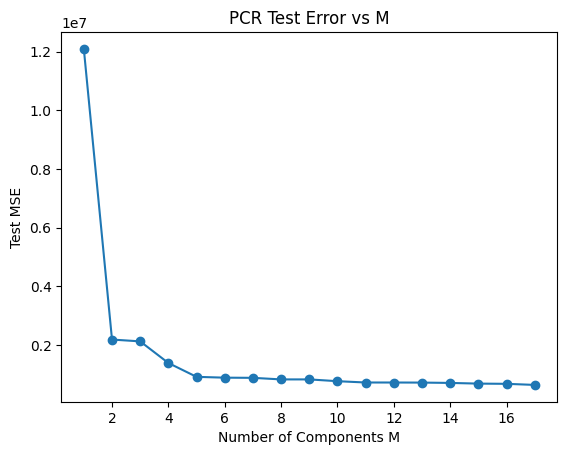

In [12]:
def pcr_cv(X_train, y_train, X_test, y_test, max_M=20):
    n_features = X_train.shape[1]
    max_M = min(max_M, n_features)

    mse_cv = []

    for M in range(1, max_M+1):
        pca = PCA(n_components=M)
        Xtr_pca = pca.fit_transform(X_train)

        model = LinearRegression()
        model.fit(Xtr_pca, y_train)

        Xte_pca = pca.transform(X_test)
        pred = model.predict(Xte_pca)

        mse = mean_squared_error(y_test, pred)
        mse_cv.append(mse)

    best_M = np.argmin(mse_cv) + 1
    best_mse = mse_cv[best_M-1]

    return best_M, best_mse, mse_cv

best_M, mse_pcr, mse_list = pcr_cv(X_train, y_train, X_test, y_test, max_M=20)

print("\n(e) PCR Test MSE:", mse_pcr)
print("    Best M:", best_M)

plt.plot(range(1, len(mse_list)+1), mse_list, marker='o')
plt.xlabel("Number of Components M")
plt.ylabel("Test MSE")
plt.title("PCR Test Error vs M")
plt.show()